# Parameter sweeps and persistence

A **sweep** builds one cavity per parameter combination, each with its own folder and
simulations, so a whole family of designs is analysed and compared in a few lines. It is a
`Study` operation (every point is a distinct, separately-saved cavity). We then show that a
saved study **reloads from disk** — cached results come back with no re-simulation, so you can
compare runs made in different sessions.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt

from cavsim2d import Study, Pillbox
from cavsim2d.utils.style import apply_style, WARM

apply_style()

## 1. A tensor sweep

`study.sweep(template, {var: values}, mode='tensor')` sweeps **every combination** of the
given values (a cartesian grid). Each point is `template.rebuild(...)` with the swept
variables overridden, so it works for any model and any variable — a multicell `'Req'` would
correctly set every cell.

In [2]:
study = Study(os.path.join(tempfile.mkdtemp(), 'sweep_demo'))
template = Pillbox(1, [100, 100, 20, 0, 50], beampipe='both')

sw = study.sweep(template, {'Req': [95, 100, 105], 'Ri': [18, 20]}, mode='tensor')
print(f'{len(sw.cavities_list)} cavities (3 x 2 grid)')
sw.sweep_table

6 cavities (3 x 2 grid)


,Req,Ri
Req95_Ri18,95,18
Req95_Ri20,95,20
Req100_Ri18,100,18
Req100_Ri20,100,20
Req105_Ri18,105,18
Req105_Ri20,105,20


Run any analysis on the sweep exactly as on any study, then read one table that **joins the**
**swept values with the QOIs** via `results()`:

In [3]:
sw.run_eigenmode({'polarisation': 'monopole', 'mesh_config': {'h': 12, 'p': 2}})
res = sw.results('eigenmode')
res[['Req', 'Ri', 'freq [MHz]', 'R/Q [Ohm]', 'Epk/Eacc []']].round(2)

,Req,Ri,freq [MHz],R/Q [Ohm],Epk/Eacc []
Req95_Ri18,95,18,1212.57,193.71,3.36
Req95_Ri20,95,20,1214.27,188.49,3.82
Req100_Ri18,100,18,1151.52,197.64,3.91
Req100_Ri20,100,20,1153.00,192.82,3.52
Req105_Ri18,105,18,1096.34,200.04,3.77
Req105_Ri20,105,20,1097.63,195.57,3.52


## 2. Compare

With the joined table, comparisons are a groupby. Here, frequency against equator radius for
each aperture:

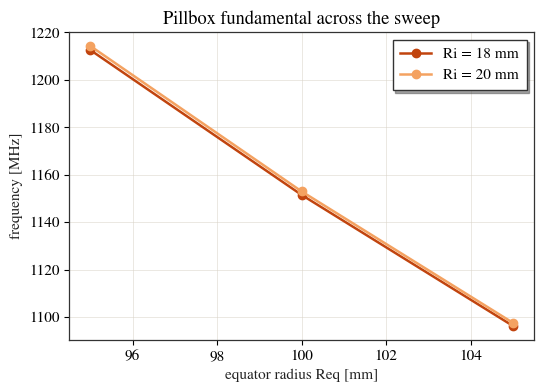

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
for i, (ri, grp) in enumerate(res.groupby('Ri')):
    g = grp.sort_values('Req')
    ax.plot(g['Req'], g['freq [MHz]'], 'o-', color=WARM[1 + 2 * i], label=f'Ri = {ri} mm')
ax.set_xlabel('equator radius Req [mm]')
ax.set_ylabel('frequency [MHz]')
ax.legend()
ax.set_title('Pillbox fundamental across the sweep')
plt.show()

The built-in study comparison plots work too, since a sweep *is* a study:

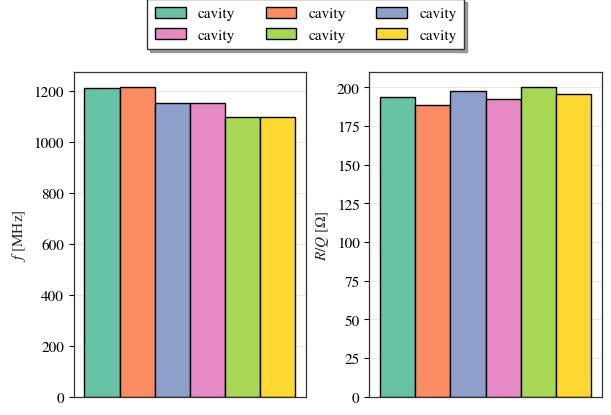

In [5]:
sw.eigenmode.plot_compare(kind='bar', qois=['freq [MHz]', 'R/Q [Ohm]'])

## 3. Hadamard (element-wise) sweep

`mode='hadamard'` pairs the value lists element-wise instead of taking the full grid — so
`{'Req': [98, 102], 'Ri': [19, 21]}` gives just two cavities, `(98, 19)` and `(102, 21)`. Every
value list must therefore be the **same length**; an unequal set is rejected.

In [6]:
sw_h = study.sweep(template, {'Req': [98, 102], 'Ri': [19, 21]}, mode='hadamard')
print('hadamard cavities:', [c.name for c in sw_h.cavities_list])

try:
    study.sweep(template, {'Req': [98, 102, 106], 'Ri': [19, 21]}, mode='hadamard')
except ValueError as e:
    print('unequal lengths rejected:', e)

hadamard cavities: ['Req98_Ri19', 'Req102_Ri21']
unequal lengths rejected: hadamard sweep requires every parameter value list to be the same length; got {'Req': 3, 'Ri': 2}. Use mode="tensor" for a full grid.


## 4. Persistence — reload a saved study

Every cavity saved its geometry and results to disk. `Study.load(project_dir)` reconstructs the
whole collection — each cavity the right type, pointing at its existing folder — so all cached
results (`eigenmode`, `wakefield`, `tuned`) read straight back with **no re-simulation**.

In [7]:
reloaded = Study.load(sw.projectDir)
print(f'reloaded {len(reloaded.cavities_list)} cavities: '
      f'{[type(c).__name__ for c in reloaded.cavities_list][:1]} ...')

# cached QOIs come straight off disk — no solver runs here
again = reloaded.results('eigenmode')
again[['freq [MHz]', 'R/Q [Ohm]']].round(2)

reloaded 6 cavities: ['Pillbox'] ...


,freq [MHz],R/Q [Ohm]
Req100_Ri18,1151.52,197.64
Req100_Ri20,1153.00,192.82
Req105_Ri18,1096.34,200.04
Req105_Ri20,1097.63,195.57
Req95_Ri18,1212.57,193.71
Req95_Ri20,1214.27,188.49


Because a loaded study behaves like any other, two studies from different sessions (or a
loaded one against a freshly-built one) compare directly — `study.eigenmode.plot_compare()`,
`study.eigenmode.qois_df`, or by joining their `results()` tables. See the
[configuration](../../configuration) and [concepts](../../concepts) guides for the folder
layout the persistence relies on.